In [11]:
# from google.colab import files

# files.upload()

In [12]:
# from google.colab import drive
# drive.mount('/content/drive')

In [13]:
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib

In [14]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [15]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # If dataset not downloaded yet, download & unzip (comment out if already present)
# import os
# if not os.path.exists("/content/new-plant-diseases-dataset"):
#     !kaggle datasets download -d vipooooool/new-plant-diseases-dataset -p /content
#     !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset

# # Confirm dataset presence (small print)
# !ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [01:09<00:00, 41.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


**Configure the dataset path for training and validation**

In [23]:
img_size  = (224, 224)
batch_size = 32
epochs = 5

n_last_layes = 10
seed =1337

#dataset paths for train and validation

train_dir = "/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
validation_dir = "/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

for paths in [train_dir, validation_dir]:
    if  not os.path.exists(paths):
        print(f"Path not found : {paths}")

print("train_dir : ",train_dir)
print("validation_dir : ",validation_dir)

train_dir :  /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
validation_dir :  /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


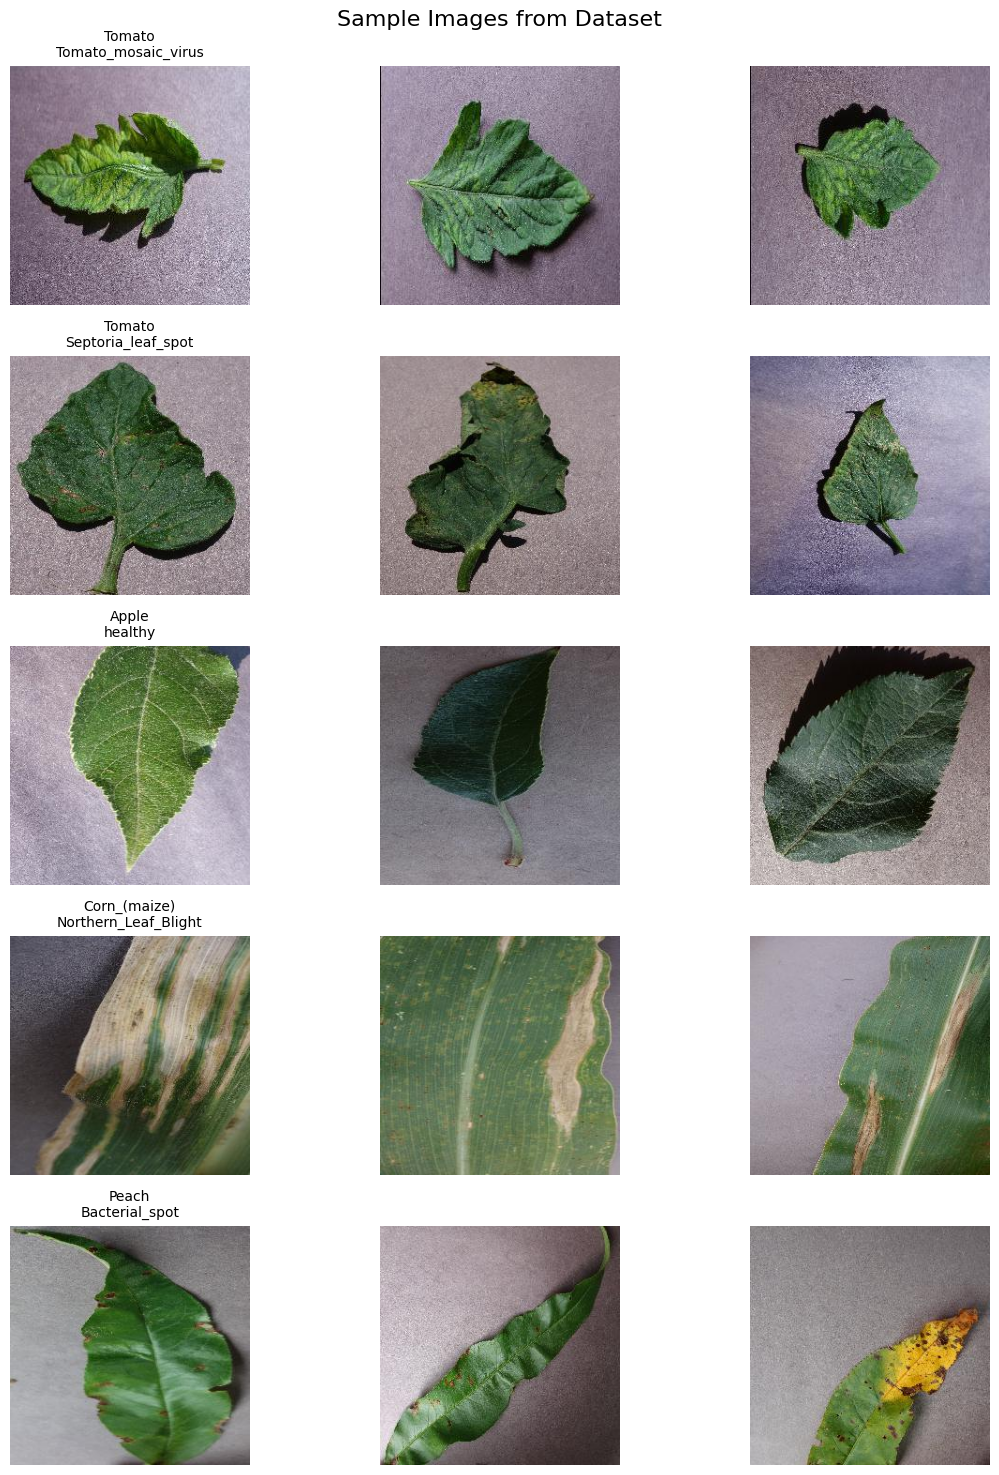

In [25]:
import random
from IPython.display import Image, display

# Function to display random samples from each class
def show_sample_images(base_path, num_classes=5, images_per_class=3):
    """Display random sample images from the dataset"""
    class_names = os.listdir(base_path)
    random_classes = random.sample(class_names, min(num_classes, len(class_names)))

    fig, axes = plt.subplots(num_classes, images_per_class,
                             figsize=(12, 3*num_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16)

    for i, class_name in enumerate(random_classes):
        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        random_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(random_images):
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.replace('___', '\n'), fontsize=10)

    plt.tight_layout()
    plt.show()

# Call the function to display sample images from the training directory
show_sample_images(train_dir)

**Datset Statistics**



In [27]:
# Count images in each split
def count_images(directory):
    """Count total images and images per class"""
    total_images = 0
    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    return total_images, class_counts

# Get statistics
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(validation_dir)

print(f"Training images: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")
print(f"\nClass distribution (first 10):")
for i, (class_name, count) in enumerate(list(train_counts.items())[:10]):
    print(f"  {class_name}: {count} images")

Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (first 10):
  Soybean___healthy: 2022 images
  Cherry_(including_sour)___healthy: 1826 images
  Blueberry___healthy: 1816 images
  Potato___Early_blight: 1939 images
  Tomato___healthy: 1926 images
  Strawberry___Leaf_scorch: 1774 images
  Peach___healthy: 1728 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 images
  Squash___Powdery_mildew: 1736 images
  Tomato___Septoria_leaf_spot: 1745 images


**Data Preprocessing and Augmentation**

In [29]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

# Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=seed
)

valid_gen = valid_datagen.flow_from_directory(
    validation_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


**Epic 2: Model Building**